# Predictive Modeling: Vehicle Fuel Efficiency (MPG)


### **Objective:** Compare model performance using quantitative metrics and analyze feature importance.

### **Dataset:** modeling_dataset.csv

1. Setup and Data Loading

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.tree import DecisionTreeRegressor

Matplotlib is building the font cache; this may take a moment.


In [2]:
df = pd.read_csv("modeling_dataset.csv")

y = df["Combined MPG (FT1)"]
x = df.drop("Combined MPG (FT1)", axis=1)

Identify numeric and categorical features

In [3]:
numeric_features = x.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_features = x.select_dtypes(include=['object', 'category']).columns.tolist()

Processing Pipeline

In [4]:
numeric_transformer = StandardScaler()
categorical_transformer = OneHotEncoder(handle_unknown="ignore")

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)


Get Feature Importance

In [5]:
model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", DecisionTreeRegressor(random_state=42))
])

model.fit(x, y)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['Year', 'Engine Cylinders',
                                                   'Engine Displacement']),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['Make', 'Model', 'Class',
                                                   'Drive', 'Transmission',
                                                   'Fuel Type'])])),
                ('model', DecisionTreeRegressor(random_state=42))])

In [6]:
encoded_cat_features = (
    model.named_steps["preprocessor"]
         .named_transformers_["cat"]
         .get_feature_names_out(categorical_features))

features = np.concatenate([numeric_features, encoded_cat_features])
importances = model.named_steps["model"].feature_importances_


In [7]:
feat_imp = pd.DataFrame({
    "feature": features,
    "importance": importances
})

5.4.1 Top Ten List

In [8]:
top10 = feat_imp.sort_values("importance", ascending=False).head(10)
print(top10)

                                            feature  importance
2                               Engine Displacement    0.683663
0                                              Year    0.087837
3889  Transmission_Automatic (variable gear ratios)    0.019249
3858                                  Drive_2-Wheel    0.014705
1                                  Engine Cylinders    0.014411
3826                             Class_Midsize Cars    0.010394
3890                 Transmission_Automatic 3-Speed    0.009659
127                                 Make_Volkswagen    0.005960
3852                          Class_Subcompact Cars    0.004902
3902                    Transmission_Manual 5-Speed    0.004898


5.4.2 Top Ten Bar Plot

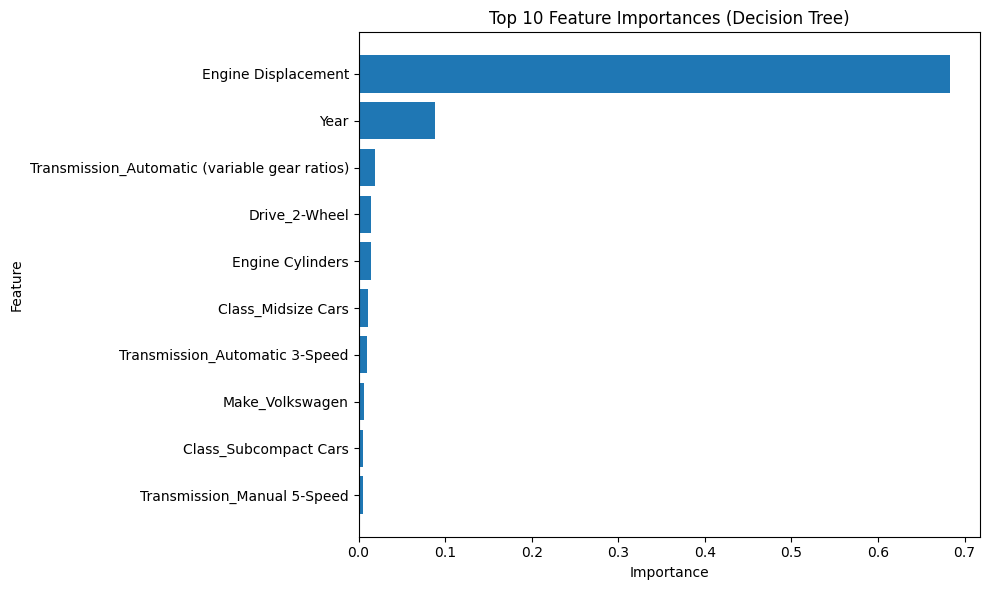

In [9]:
plt.figure(figsize=(10, 6))
plt.barh(top10["feature"], top10["importance"])
plt.gca().invert_yaxis()
plt.title("Top 10 Feature Importances (Decision Tree)")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

Insight Summary

Using the Decision Tree, it was found that Engine Displacement is the most important feature, followed by Year and certain automatic transmission types. This indicates that these features have the strongest influence on vehicle fuel efficiency. These results provide insight into the question: “Can vehicle fuel efficiency (Combined MPG) be accurately predicted using basic vehicle specifications, and which factors most strongly influence fuel economy?” Specifically, the analysis shows that larger engines and older vehicles tend to lower MPG, while newer models and advanced transmission designs tend to increase it, highlighting which specifications are most critical for predicting fuel efficiency.